# Linear Regression Lab — Hours Studied vs Exam Score

**CS570 Big Data Processing & Analytics — Week 7**

We just did this in Excel. Now let's do the exact same thing in Python 
and confirm we get the same numbers.

In [2]:
import subprocess
subprocess.run(["pip", "install", "matplotlib"], check=True)


CompletedProcess(args=['pip', 'install', 'matplotlib'], returncode=0)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the Data

In [4]:
df = pd.read_csv("hours_vs_score.csv")
print(f"Rows: {len(df)}")
df.head(10)

Rows: 20


,Hours,Score
0,1.0,45.7
1,1.5,45.1
2,2.0,51.6
3,2.5,58.6
4,3.0,52.4
5,3.5,55.0
6,4.0,66.7
7,4.5,65.2
8,5.0,61.7
9,5.5,69.3


In [5]:
df.describe()

,Hours,Score
count,20.000000,20.000000
mean,5.575000,66.130000
std,2.759076,12.110895
min,1.000000,45.100000
25%,3.375000,57.700000
50%,5.750000,66.800000
75%,7.625000,75.900000
max,10.000000,86.400000


## Scatter Plot

Same picture you saw in Excel — just with matplotlib.

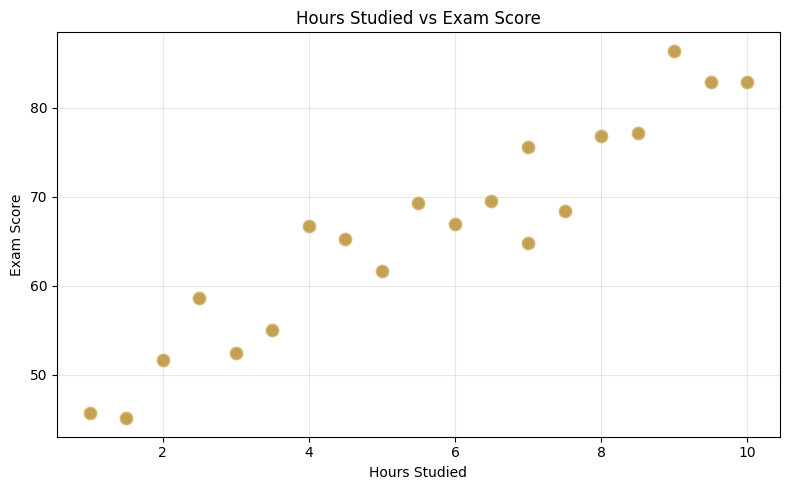

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Hours"], df["Score"], color="#C4A052", edgecolors="#D4B872", s=80)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Fit the Line

`np.polyfit(x, y, 1)` fits a degree-1 polynomial (a line) to the data.  
It returns `[slope, intercept]` — the same two numbers Excel gave you.

In [7]:
slope, intercept = np.polyfit(df["Hours"], df["Score"], 1)

print(f"Slope:     {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"\nModel: score = {slope:.2f} × hours + {intercept:.2f}")

Slope:     4.1618
Intercept: 42.9279

Model: score = 4.16 × hours + 42.93


## Plot the Regression Line

Overlay the best-fit line on the scatter plot.

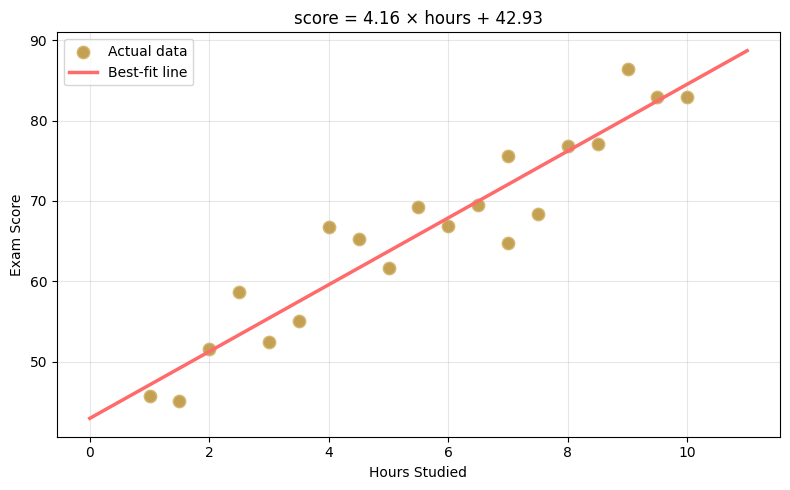

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Hours"], df["Score"], color="#C4A052", edgecolors="#D4B872",
            s=80, label="Actual data")

# Draw the regression line
x_line = np.linspace(0, 11, 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color="#FF6B6B", linewidth=2.5, label="Best-fit line")

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title(f"score = {slope:.2f} × hours + {intercept:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Predictions and RMSE

Compute predicted scores, errors, and RMSE — then compare to your Excel answer.

In [9]:
# Predicted score for each student
df["Predicted"] = slope * df["Hours"] + intercept

# Error = predicted - actual
df["Error"] = df["Predicted"] - df["Score"]

df.head(10)

,Hours,Score,Predicted,Error
0,1.0,45.7,47.089681,1.389681
1,1.5,45.1,49.170590,4.070590
2,2.0,51.6,51.251499,-0.348501
3,2.5,58.6,53.332409,-5.267591
4,3.0,52.4,55.413318,3.013318
5,3.5,55.0,57.494227,2.494227
6,4.0,66.7,59.575136,-7.124864
7,4.5,65.2,61.656045,-3.543955
8,5.0,61.7,63.736954,2.036954
9,5.5,69.3,65.817864,-3.482136


In [10]:
# Root Mean Squared Error
rmse = np.sqrt(np.mean(df["Error"] ** 2))
print(f"RMSE = {rmse:.4f}")
print(f"\nInterpretation: on average, predictions are off by ~{rmse:.1f} points")
print("\n→ Compare this to your Excel RMSE — same number?")

RMSE = 3.7522

Interpretation: on average, predictions are off by ~3.8 points

→ Compare this to your Excel RMSE — same number?


## Make a Prediction

A student studied for **7.5 hours**. What does the model predict?

In [11]:
new_hours = 7.5
predicted_score = slope * new_hours + intercept

print(f"If a student studies {new_hours} hours:")
print(f"  Predicted score = {slope:.2f} × {new_hours} + {intercept:.2f}")
print(f"  Predicted score = {predicted_score:.1f}")

If a student studies 7.5 hours:
  Predicted score = 4.16 × 7.5 + 42.93
  Predicted score = 74.1


## Visualize the Prediction

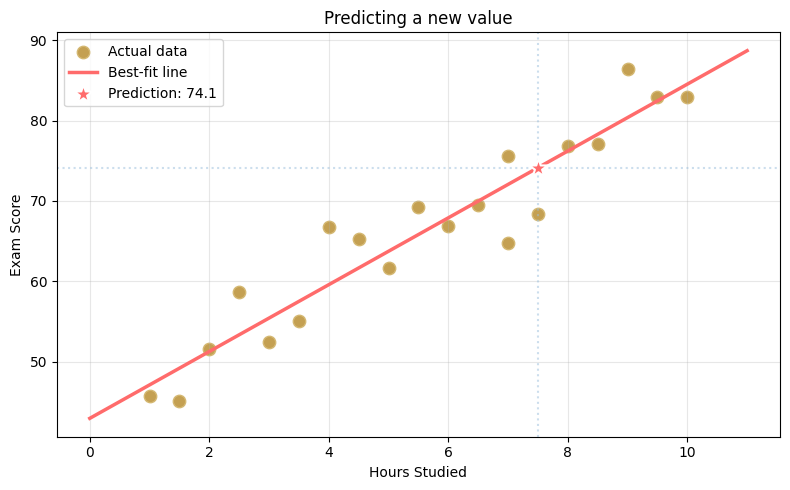

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Hours"], df["Score"], color="#C4A052", edgecolors="#D4B872",
            s=80, label="Actual data")
plt.plot(x_line, y_line, color="#FF6B6B", linewidth=2.5, label="Best-fit line")

# Highlight the prediction
plt.scatter([new_hours], [predicted_score], color="#FF6B6B", s=200,
            marker="*", zorder=5, edgecolors="white", linewidths=1.5,
            label=f"Prediction: {predicted_score:.1f}")
plt.axvline(x=new_hours, color="#9BBFDC", linestyle=":", alpha=0.5)
plt.axhline(y=predicted_score, color="#9BBFDC", linestyle=":", alpha=0.5)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Predicting a new value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Exit Ticket

**A student studied for 7.5 hours. Using the model we built, what exam score does our line predict?**

Show the calculation:  `score = slope × 7.5 + intercept`